In [ ]:
# Cell 1

!pip install -q opencv-python-headless scikit-image pandas matplotlib tqdm scikit-learn gdown

In [2]:
# Cell 2

import os
import re
import cv2
import math
import glob
import json
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from scipy.optimize import nnls
from scipy.stats import pearsonr, spearmanr

from skimage.filters import threshold_otsu
from skimage.feature import local_binary_pattern

warnings.filterwarnings("ignore")

In [3]:
# Cell 3

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Cell 4

# Folder that already contains the extracted dataset
DATASET_DIR = "/content/drive/MyDrive/DeepSolarEye/Solar_Panel_Soiling_Image_dataset/PanelImages"

# Search all jpg images inside it
IMAGE_GLOB = os.path.join(DATASET_DIR, "**", "*.jpg")

# Random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Resize resolution used for analysis
IMG_W = 320
IMG_H = 240

# ROI margins as fractions
TOP_FRAC = 0.08
BOTTOM_FRAC = 0.08
LEFT_FRAC = 0.06
RIGHT_FRAC = 0.06

# Reference image selection
REF_MAX_LOSS = 0.03
REF_MIN_IRR_Q = 0.55
N_REF_IMAGES = 120

# Evaluation sizes
N_CALIB = 5000
N_TEST = 20000

# Save directory
ARTIFACT_DIR = "/content/soiling_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [6]:
# Cell 5

all_image_paths = sorted(glob.glob(IMAGE_GLOB, recursive=True))
print("Number of images found:", len(all_image_paths))

# quick peek
all_image_paths[:5]

Number of images found: 45754


['/content/drive/MyDrive/DeepSolarEye/Solar_Panel_Soiling_Image_dataset/PanelImages/solar_Fri_Jun_16_10__0__11_2017_L_0.906153208302_I_0.321592156863.jpg',
 '/content/drive/MyDrive/DeepSolarEye/Solar_Panel_Soiling_Image_dataset/PanelImages/solar_Fri_Jun_16_10__0__16_2017_L_0.903081697073_I_0.293192156863.jpg',
 '/content/drive/MyDrive/DeepSolarEye/Solar_Panel_Soiling_Image_dataset/PanelImages/solar_Fri_Jun_16_10__0__1_2017_L_0.916698044034_I_0.39577254902.jpg',
 '/content/drive/MyDrive/DeepSolarEye/Solar_Panel_Soiling_Image_dataset/PanelImages/solar_Fri_Jun_16_10__0__21_2017_L_0.903081697073_I_0.293192156863.jpg',
 '/content/drive/MyDrive/DeepSolarEye/Solar_Panel_Soiling_Image_dataset/PanelImages/solar_Fri_Jun_16_10__0__26_2017_L_0.896087391118_I_0.27462745098.jpg']

In [7]:
# Cell 6

FILENAME_RE = re.compile(
    r"solar_(?P<timestamp>.+?)_L_(?P<loss>[0-9]*\.?[0-9]+)_I_(?P<irr>[0-9]*\.?[0-9]+)\.jpg$"
)

def parse_labels_from_path(path):
    name = os.path.basename(path)
    m = FILENAME_RE.match(name)
    if not m:
        return None

    return {
        "path": path,
        "filename": name,
        "timestamp_raw": m.group("timestamp"),
        "loss": float(m.group("loss")),   # expected in [0,1] on this dataset
        "irradiance": float(m.group("irr"))
    }

records = []
for p in tqdm(all_image_paths):
    row = parse_labels_from_path(p)
    if row is not None:
        records.append(row)

df = pd.DataFrame(records)
print("Parsed rows:", len(df))
df.head()

100%|██████████| 45754/45754 [00:00<00:00, 215558.08it/s]


Parsed rows: 45721


,path,filename,timestamp_raw,loss,irradiance
0,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Fri_Jun_16_10__0__11_2017_L_0.9061532083...,Fri_Jun_16_10__0__11_2017,0.906153,0.321592
1,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Fri_Jun_16_10__0__16_2017_L_0.9030816970...,Fri_Jun_16_10__0__16_2017,0.903082,0.293192
2,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Fri_Jun_16_10__0__1_2017_L_0.91669804403...,Fri_Jun_16_10__0__1_2017,0.916698,0.395773
3,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Fri_Jun_16_10__0__21_2017_L_0.9030816970...,Fri_Jun_16_10__0__21_2017,0.903082,0.293192
4,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Fri_Jun_16_10__0__26_2017_L_0.8960873911...,Fri_Jun_16_10__0__26_2017,0.896087,0.274627


               loss    irradiance
count  45721.000000  45721.000000
mean       0.265289      0.345824
std        0.284070      0.206185
min        0.000000      0.002682
25%        0.031849      0.189627
50%        0.119965      0.310827
75%        0.522654      0.483886
max        0.996159      1.006125


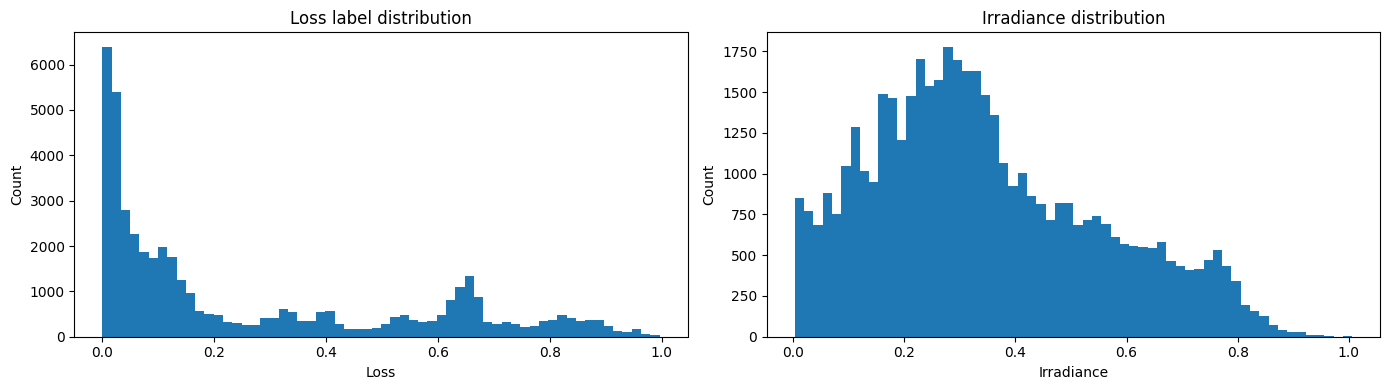

In [8]:
# Cell 7

print(df[["loss", "irradiance"]].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df["loss"], bins=60)
ax[0].set_title("Loss label distribution")
ax[0].set_xlabel("Loss")
ax[0].set_ylabel("Count")

ax[1].hist(df["irradiance"], bins=60)
ax[1].set_title("Irradiance distribution")
ax[1].set_xlabel("Irradiance")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
# Cell 8

def read_bgr(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Failed to read image: {path}")
    return img

def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def resize_img(img, w=IMG_W, h=IMG_H):
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

def fixed_roi_crop(img):
    h, w = img.shape[:2]
    y1 = int(h * TOP_FRAC)
    y2 = int(h * (1 - BOTTOM_FRAC))
    x1 = int(w * LEFT_FRAC)
    x2 = int(w * (1 - RIGHT_FRAC))
    return img[y1:y2, x1:x2]

def preprocess_base(img_bgr):
    """
    Classical preprocessing:
    - resize
    - fixed ROI crop
    - denoise
    - LAB conversion
    - CLAHE on L channel
    """
    img = resize_img(img_bgr)
    roi = fixed_roi_crop(img)

    den = cv2.bilateralFilter(roi, 5, 30, 30)

    lab = cv2.cvtColor(den, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)

    lab_eq = cv2.merge([l_eq, a, b])
    bgr_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    gray_eq = cv2.cvtColor(bgr_eq, cv2.COLOR_BGR2GRAY)

    return {
        "raw_resized": img,
        "roi": roi,
        "denoised": den,
        "lab_eq": lab_eq,
        "bgr_eq": bgr_eq,
        "gray_eq": gray_eq
    }

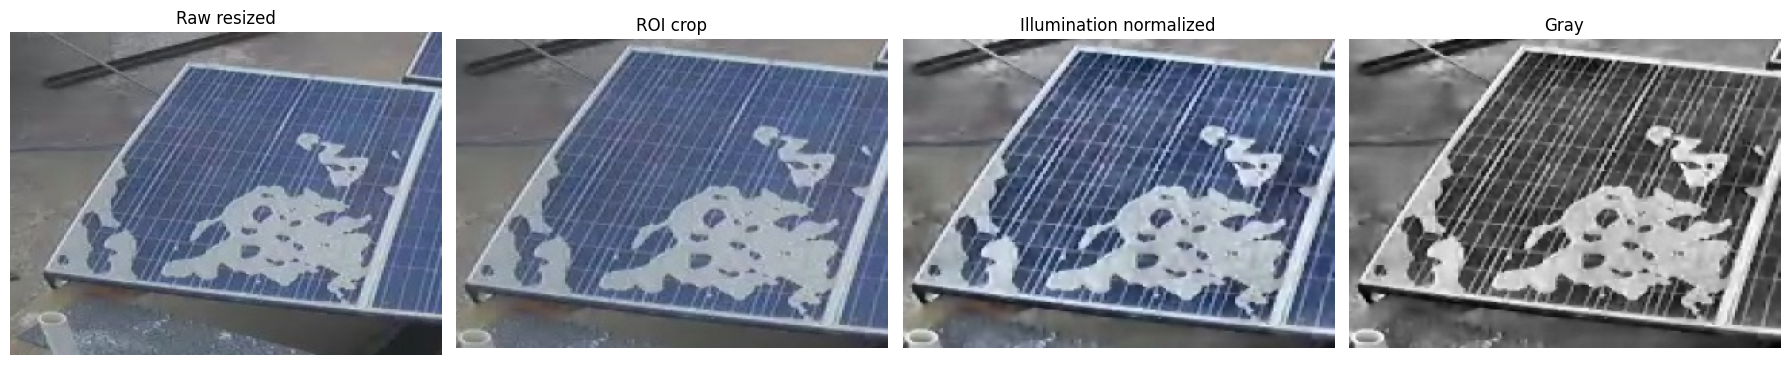

In [10]:
# Cell 9

sample_path = df.sample(1, random_state=SEED).iloc[0]["path"]
sample = preprocess_base(read_bgr(sample_path))

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(bgr_to_rgb(sample["raw_resized"]))
ax[0].set_title("Raw resized")
ax[1].imshow(bgr_to_rgb(sample["roi"]))
ax[1].set_title("ROI crop")
ax[2].imshow(bgr_to_rgb(sample["bgr_eq"]))
ax[2].set_title("Illumination normalized")
ax[3].imshow(sample["gray_eq"], cmap="gray")
ax[3].set_title("Gray")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# Cell 10

irr_q = df["irradiance"].quantile(REF_MIN_IRR_Q)

ref_candidates = df[
    (df["loss"] <= REF_MAX_LOSS) &
    (df["irradiance"] >= irr_q)
].copy()

print("Reference candidates:", len(ref_candidates))

if len(ref_candidates) < N_REF_IMAGES:
    print("Not enough strict reference images, relaxing condition...")
    ref_candidates = df[
        (df["loss"] <= max(REF_MAX_LOSS, 0.05)) &
        (df["irradiance"] >= df["irradiance"].quantile(0.40))
    ].copy()

ref_candidates = ref_candidates.sample(
    n=min(N_REF_IMAGES, len(ref_candidates)),
    random_state=SEED
).reset_index(drop=True)

print("Reference images selected:", len(ref_candidates))
ref_candidates.head()

Reference candidates: 4166
Reference images selected: 120


,path,filename,timestamp_raw,loss,irradiance
0,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Sun_Jun_25_9__6__34_2017_L_0.00916068720...,Sun_Jun_25_9__6__34_2017,0.009161,0.501718
1,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Mon_Jun_26_11__45__14_2017_L_0.011600452...,Mon_Jun_26_11__45__14_2017,0.011600,0.363745
2,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Sat_Jun_24_10__36__10_2017_L_0.006388720...,Sat_Jun_24_10__36__10_2017,0.006389,0.581294
3,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Mon_Jun_26_12__34__5_2017_L_0.0181662776...,Mon_Jun_26_12__34__5_2017,0.018166,0.885502
4,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,solar_Wed_Jun_14_13__49__17_2017_L_0.002747252...,Wed_Jun_14_13__49__17_2017,0.002747,0.518165


100%|██████████| 120/120 [02:08<00:00,  1.07s/it]


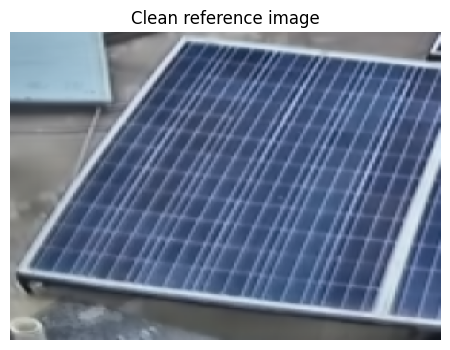

True

In [12]:
# Cell 11

def build_reference_image(paths):
    acc = None
    count = 0
    for p in tqdm(paths):
        proc = preprocess_base(read_bgr(p))
        img = proc["bgr_eq"].astype(np.float32)
        if acc is None:
            acc = np.zeros_like(img, dtype=np.float32)
        acc += img
        count += 1
    ref = (acc / max(count, 1)).astype(np.uint8)
    return ref

reference_bgr = build_reference_image(ref_candidates["path"].tolist())
reference_gray = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2GRAY)
reference_lab = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(6, 4))
plt.imshow(bgr_to_rgb(reference_bgr))
plt.title("Clean reference image")
plt.axis("off")
plt.show()

cv2.imwrite(os.path.join(ARTIFACT_DIR, "reference_bgr.png"), reference_bgr)

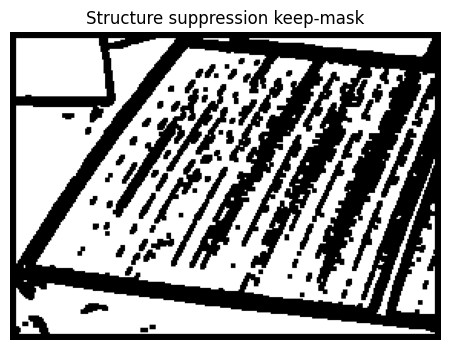

In [13]:
# Cell 12

def build_structure_suppression_mask(gray_img):
    """
    Suppress grid/edges a bit using morphology + gradient.
    Output: mask where 1 means keep, 0 means suppress
    """
    blur = cv2.GaussianBlur(gray_img, (5, 5), 0)

    grad_x = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(grad_x, grad_y)

    mag_n = mag / (mag.max() + 1e-6)
    edge_mask = (mag_n > 0.28).astype(np.uint8)

    # dilate edge regions slightly
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edge_mask = cv2.dilate(edge_mask, kernel, iterations=1)

    # also suppress thin border
    keep = np.ones_like(edge_mask, dtype=np.uint8)
    keep[:4, :] = 0
    keep[-4:, :] = 0
    keep[:, :4] = 0
    keep[:, -4:] = 0

    keep = keep * (1 - edge_mask)
    return keep

structure_keep_mask = build_structure_suppression_mask(reference_gray)

plt.figure(figsize=(6, 4))
plt.imshow(structure_keep_mask, cmap="gray")
plt.title("Structure suppression keep-mask")
plt.axis("off")
plt.show()

In [14]:
# Cell 13

def local_variance(gray, ksize=9):
    gray_f = gray.astype(np.float32)
    mean = cv2.blur(gray_f, (ksize, ksize))
    mean_sq = cv2.blur(gray_f * gray_f, (ksize, ksize))
    var = np.maximum(mean_sq - mean * mean, 0.0)
    return var

In [15]:
# Cell 14

def extract_classical_features(img_bgr, ref_bgr=reference_bgr, ref_gray=reference_gray, ref_lab=reference_lab):
    proc = preprocess_base(img_bgr)
    cur_bgr = proc["bgr_eq"]
    cur_gray = proc["gray_eq"]
    cur_lab = cv2.cvtColor(cur_bgr, cv2.COLOR_BGR2LAB)

    # ----- 1) grayscale difference -----
    diff_gray = cv2.absdiff(cur_gray, ref_gray).astype(np.float32) / 255.0

    # ----- 2) color difference in LAB -----
    dlab = cur_lab.astype(np.float32) - ref_lab.astype(np.float32)
    delta_lab = np.sqrt(np.sum(dlab**2, axis=2))
    delta_lab_n = delta_lab / (delta_lab.max() + 1e-6)

    # ----- 3) texture degradation -----
    var_ref = local_variance(ref_gray, 9)
    var_cur = local_variance(cur_gray, 9)
    texture_drop = np.maximum(var_ref - var_cur, 0.0)
    texture_drop_n = texture_drop / (texture_drop.max() + 1e-6)

    # ----- 4) darkness / haze-like deviation -----
    ref_f = ref_gray.astype(np.float32)
    cur_f = cur_gray.astype(np.float32)
    signed = (ref_f - cur_f) / 255.0
    dark_map = np.clip(signed, 0, 1)

    # combine dirty evidence
    combined = (
        0.34 * diff_gray +
        0.28 * delta_lab_n +
        0.23 * texture_drop_n +
        0.15 * dark_map
    )

    # suppress fixed structure / border
    combined = combined * structure_keep_mask

    # smooth
    combined_blur = cv2.GaussianBlur(combined.astype(np.float32), (5, 5), 0)

    # adaptive threshold
    thr = threshold_otsu((combined_blur * 255).astype(np.uint8)) / 255.0
    # slightly stricter than pure otsu to reduce false positives
    thr = min(max(thr * 1.08, 0.08), 0.70)

    mask = (combined_blur >= thr).astype(np.uint8)

    # morphology cleanup
    kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel5)

    # remove tiny blobs
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    min_area = int(mask.size * 0.0015)
    for i in range(1, n_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 1
    mask = cleaned

    # ---------- components ----------
    # A: dirty area ratio
    A = float(mask.mean())

    # C: color deviation under mask and globally
    if mask.sum() > 0:
        C = float(delta_lab_n[mask == 1].mean())
    else:
        C = float(delta_lab_n.mean() * 0.3)

    # T: texture degradation
    if mask.sum() > 0:
        T = float(texture_drop_n[mask == 1].mean())
    else:
        T = float(texture_drop_n.mean() * 0.3)

    # N: patchiness / non-uniformity
    # combine largest blob ratio + block-density std
    n_labels2, labels2, stats2, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    areas = stats2[1:, cv2.CC_STAT_AREA] if n_labels2 > 1 else np.array([0])
    largest_ratio = float((areas.max() if len(areas) else 0) / (mask.size + 1e-6))

    bh, bw = 6, 8
    hh, ww = mask.shape
    block_vals = []
    for yy in np.array_split(np.arange(hh), bh):
        for xx in np.array_split(np.arange(ww), bw):
            block = mask[np.ix_(yy, xx)]
            block_vals.append(block.mean())
    block_vals = np.array(block_vals, dtype=np.float32)
    density_std = float(block_vals.std())

    N = float(0.6 * largest_ratio + 0.4 * density_std)

    # extra diagnostics
    return {
        "proc": proc,
        "diff_gray": diff_gray,
        "delta_lab_n": delta_lab_n,
        "texture_drop_n": texture_drop_n,
        "dark_map": dark_map,
        "combined": combined,
        "combined_blur": combined_blur,
        "mask": mask,
        "A": A,
        "C": C,
        "T": T,
        "N": N
    }

True loss: 0.838014667843
A, C, T, N = 0.13627591579469203 0.5544835925102234 0.022619852796196938 0.11020529627387193


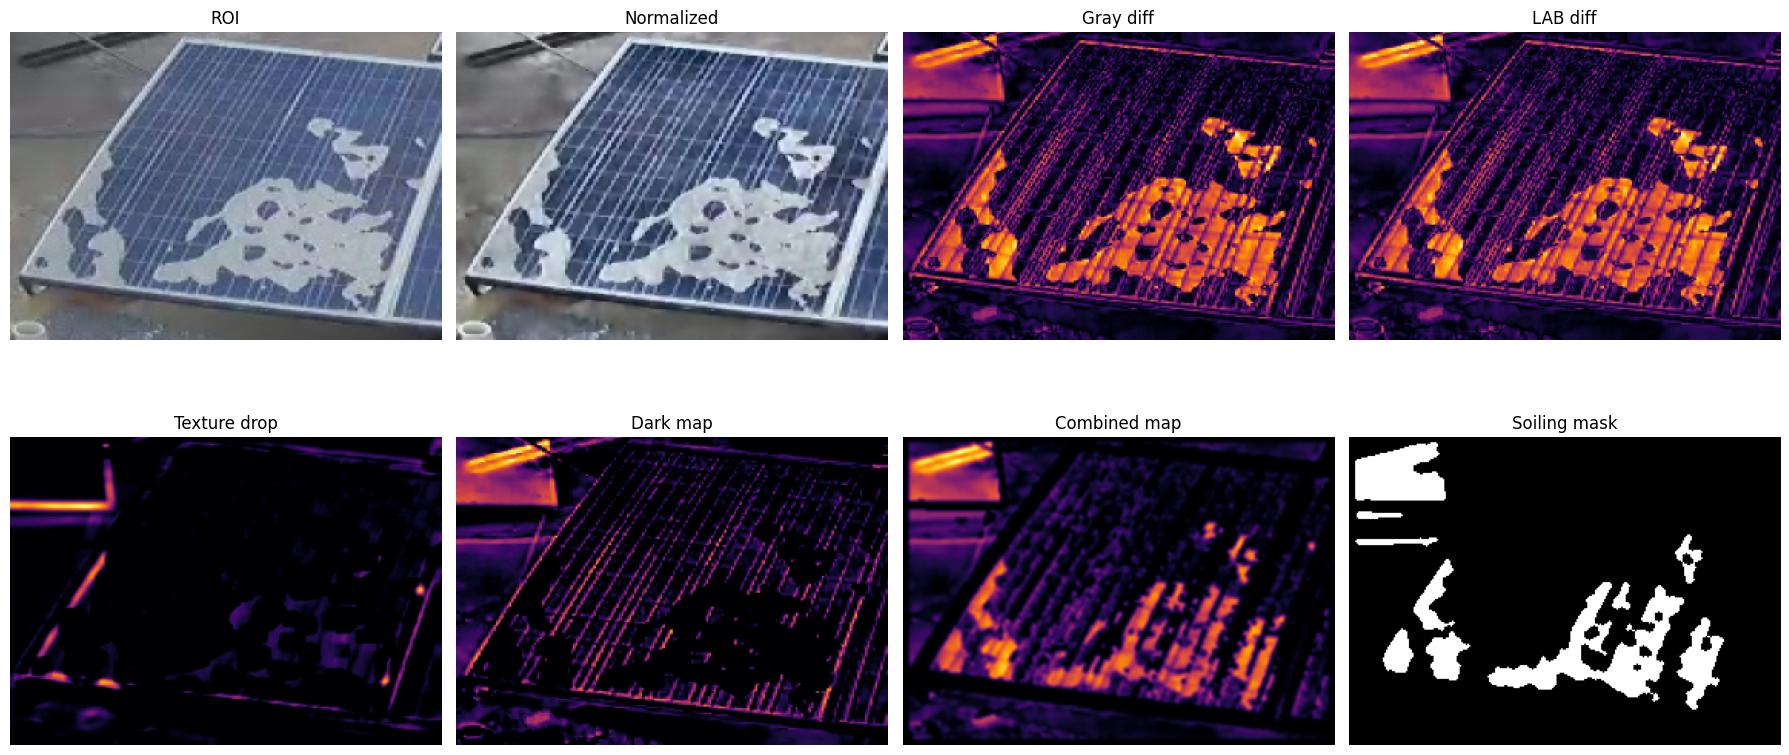

In [16]:
# Cell 15

test_row = df.sample(1, random_state=SEED).iloc[0]
out = extract_classical_features(read_bgr(test_row["path"]))

print("True loss:", test_row["loss"])
print("A, C, T, N =", out["A"], out["C"], out["T"], out["N"])

fig, ax = plt.subplots(2, 4, figsize=(18, 9))
ax[0,0].imshow(bgr_to_rgb(out["proc"]["roi"]))
ax[0,0].set_title("ROI")
ax[0,1].imshow(bgr_to_rgb(out["proc"]["bgr_eq"]))
ax[0,1].set_title("Normalized")
ax[0,2].imshow(out["diff_gray"], cmap="inferno")
ax[0,2].set_title("Gray diff")
ax[0,3].imshow(out["delta_lab_n"], cmap="inferno")
ax[0,3].set_title("LAB diff")

ax[1,0].imshow(out["texture_drop_n"], cmap="inferno")
ax[1,0].set_title("Texture drop")
ax[1,1].imshow(out["dark_map"], cmap="inferno")
ax[1,1].set_title("Dark map")
ax[1,2].imshow(out["combined_blur"], cmap="inferno")
ax[1,2].set_title("Combined map")
ax[1,3].imshow(out["mask"], cmap="gray")
ax[1,3].set_title("Soiling mask")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Cell 16

ref_set = set(ref_candidates["path"].tolist())
remaining_df = df[~df["path"].isin(ref_set)].copy().reset_index(drop=True)

print("Remaining after reference removal:", len(remaining_df))

# We keep enough for calibration and test
assert len(remaining_df) >= (N_CALIB + N_TEST), "Not enough images remaining."

calib_df = remaining_df.sample(n=N_CALIB, random_state=SEED)
rest_df = remaining_df.drop(calib_df.index).reset_index(drop=True)
test_df = rest_df.sample(n=N_TEST, random_state=SEED).reset_index(drop=True)

calib_df = calib_df.reset_index(drop=True)

print("Calibration:", len(calib_df))
print("Test:", len(test_df))

Remaining after reference removal: 45601
Calibration: 5000
Test: 20000


In [18]:
# Cell 17

def feature_table_from_df(df_in, desc="Extracting features"):
    rows = []
    for _, row in tqdm(df_in.iterrows(), total=len(df_in), desc=desc):
        try:
            img = read_bgr(row["path"])
            feat = extract_classical_features(img)
            rows.append({
                "path": row["path"],
                "loss": row["loss"],
                "irradiance": row["irradiance"],
                "A": feat["A"],
                "C": feat["C"],
                "T": feat["T"],
                "N": feat["N"]
            })
        except Exception as e:
            # skip unreadable images
            continue
    return pd.DataFrame(rows)

calib_feats = feature_table_from_df(calib_df, desc="Calibration features")
calib_feats.head()

Calibration features: 100%|██████████| 5000/5000 [46:48<00:00,  1.78it/s]


,path,loss,irradiance,A,C,T,N
0,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.169935,0.312208,0.096156,0.273731,0.006776,0.057253
1,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.544561,0.468929,0.184469,0.288249,0.006026,0.128103
2,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.902754,0.675102,0.166764,0.407650,0.023762,0.080409
3,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.343430,0.118596,0.108426,0.290299,0.019528,0.098463
4,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.002187,0.105816,0.134541,0.283135,0.002014,0.114709


In [19]:
# Cell 18

X_cal = calib_feats[["A", "C", "T", "N"]].values.astype(np.float64)
y_cal = calib_feats["loss"].values.astype(np.float64)

# Normalize columns to comparable scale first
col_max = np.maximum(X_cal.max(axis=0), 1e-8)
Xn = X_cal / col_max

# non-negative least squares
w_raw, _ = nnls(Xn, y_cal)
w = w_raw / (w_raw.sum() + 1e-8)

print("Optimized weights [A, C, T, N]:", w)

Optimized weights [A, C, T, N]: [0.         0.97246593 0.02753405 0.        ]


In [20]:
# Cell 19

def raw_soiling_index_from_components(A, C, T, N, w, col_max):
    x = np.array([A, C, T, N], dtype=np.float64) / col_max
    score = float(np.dot(w, x))
    return score

calib_scores = []
for _, row in calib_feats.iterrows():
    s = raw_soiling_index_from_components(row["A"], row["C"], row["T"], row["N"], w, col_max)
    calib_scores.append(s)

calib_feats["score_raw"] = calib_scores

# Fit isotonic regression: monotonic mapping score -> loss
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(calib_feats["score_raw"].values, calib_feats["loss"].values)

# Convert raw score to 0-100 Soiling Index for presentation
score_min = float(np.percentile(calib_feats["score_raw"], 1))
score_max = float(np.percentile(calib_feats["score_raw"], 99))

def score_to_si(score):
    si = 100.0 * (score - score_min) / (score_max - score_min + 1e-8)
    return float(np.clip(si, 0, 100))

def score_to_loss(score):
    return float(np.clip(iso.predict([score])[0], 0, 1))

calib_feats["soiling_index"] = calib_feats["score_raw"].apply(score_to_si)
calib_feats["pred_loss"] = calib_feats["score_raw"].apply(score_to_loss)

calib_feats.head()

,path,loss,irradiance,A,C,T,N,score_raw,soiling_index,pred_loss
0,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.169935,0.312208,0.096156,0.273731,0.006776,0.057253,0.389380,13.861239,0.166662
1,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.544561,0.468929,0.184469,0.288249,0.006026,0.128103,0.409799,17.409358,0.215804
2,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.902754,0.675102,0.166764,0.407650,0.023762,0.080409,0.582736,47.460448,0.507756
3,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.343430,0.118596,0.108426,0.290299,0.019528,0.098463,0.415527,18.404755,0.215804
4,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.002187,0.105816,0.134541,0.283135,0.002014,0.114709,0.401712,16.004164,0.215804


Calibration results
Pearson: 0.6676909933579506
Spearman: 0.5094194225699176
MAE: 0.16062697010297197
RMSE: 0.04518143847336221
R2: 0.445811262611327


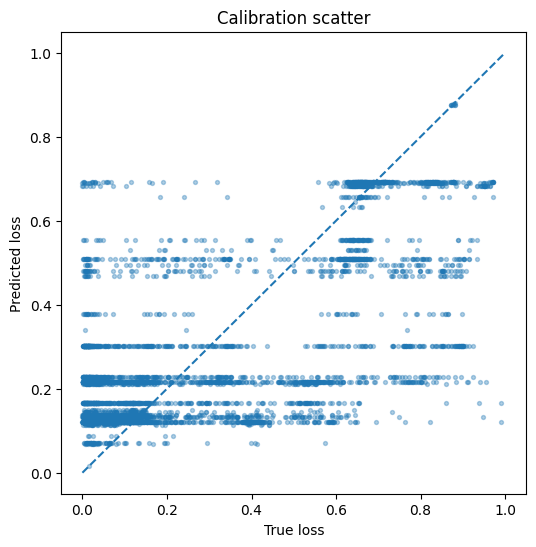

In [23]:
# Cell 20

pear = pearsonr(calib_feats["pred_loss"], calib_feats["loss"])[0]
spear = spearmanr(calib_feats["pred_loss"], calib_feats["loss"])[0]
mae = mean_absolute_error(calib_feats["loss"], calib_feats["pred_loss"])
rmse = mean_squared_error(calib_feats["loss"], calib_feats["pred_loss"])
r2 = r2_score(calib_feats["loss"], calib_feats["pred_loss"])

print("Calibration results")
print("Pearson:", pear)
print("Spearman:", spear)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

plt.figure(figsize=(6, 6))
plt.scatter(calib_feats["loss"], calib_feats["pred_loss"], s=8, alpha=0.35)
plt.xlabel("True loss")
plt.ylabel("Predicted loss")
plt.title("Calibration scatter")
plt.plot([0, 1], [0, 1], "--")
plt.show()

In [25]:
# Cell 21

test_feats = feature_table_from_df(test_df, desc="Test features")
print("Usable test rows:", len(test_feats))
test_feats.head()

Test features: 100%|██████████| 20000/20000 [06:02<00:00, 55.16it/s]

Usable test rows: 20000


,path,loss,irradiance,A,C,T,N
0,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.011786,0.297800,0.137515,0.360683,0.007723,0.091643
1,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.124361,0.145843,0.080540,0.359425,0.025944,0.099396
2,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.165254,0.187329,0.179228,0.250467,0.007000,0.089808
3,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.417819,0.229145,0.064588,0.247683,0.012258,0.055345
4,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.795966,0.402855,0.234327,0.320000,0.007622,0.118415


In [26]:
# Cell 22

test_scores = []
for _, row in test_feats.iterrows():
    s = raw_soiling_index_from_components(row["A"], row["C"], row["T"], row["N"], w, col_max)
    test_scores.append(s)

test_feats["score_raw"] = test_scores
test_feats["soiling_index"] = test_feats["score_raw"].apply(score_to_si)
test_feats["pred_loss"] = test_feats["score_raw"].apply(score_to_loss)

test_feats.head()

,path,loss,irradiance,A,C,T,N,score_raw,soiling_index,pred_loss
0,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.011786,0.297800,0.137515,0.360683,0.007723,0.091643,0.512816,35.310584,0.481274
1,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.124361,0.145843,0.080540,0.359425,0.025944,0.099396,0.514842,35.662658,0.481274
2,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.165254,0.187329,0.179228,0.250467,0.007000,0.089808,0.356454,8.139655,0.120499
3,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.417819,0.229145,0.064588,0.247683,0.012258,0.055345,0.353607,7.644951,0.120499
4,/content/drive/MyDrive/DeepSolarEye/Solar_Pane...,0.795966,0.402855,0.234327,0.320000,0.007622,0.118415,0.455134,25.287240,0.301859


In [28]:
# Cell 23

y_true = test_feats["loss"].values
y_pred = test_feats["pred_loss"].values

pear = pearsonr(y_true, y_pred)[0]
spear = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# event accuracy for "needs cleaning" at 5% power loss
thr = 0.05
event_true = (y_true >= thr).astype(int)
event_pred = (y_pred >= thr).astype(int)
event_acc = accuracy_score(event_true, event_pred)

# tolerance accuracy: prediction within ±5 percentage points
tol_acc = np.mean(np.abs(y_true - y_pred) <= 0.05)

def severity_bucket(x):
    if x < 0.05:
        return 0   # clean / negligible
    elif x < 0.15:
        return 1   # mild
    elif x < 0.30:
        return 2   # moderate
    else:
        return 3   # heavy

bucket_true = np.array([severity_bucket(v) for v in y_true])
bucket_pred = np.array([severity_bucket(v) for v in y_pred])
bucket_acc = accuracy_score(bucket_true, bucket_pred)

print("========== TEST RESULTS ON 20,000 IMAGES ==========")
print(f"Pearson correlation       : {pear:.4f}")
print(f"Spearman correlation      : {spear:.4f}")
print(f"MAE                       : {mae:.4f}")
print(f"RMSE                      : {rmse:.4f}")
print(f"R²                        : {r2:.4f}")
print(f"Loss>=5% event accuracy   : {event_acc*100:.2f}%")
print(f"Within ±5% loss accuracy  : {tol_acc*100:.2f}%")
print(f"Severity bucket accuracy  : {bucket_acc*100:.2f}%")

print("\nConfusion matrix for loss>=5% event:")
print(confusion_matrix(event_true, event_pred))

print("\nClassification report for loss>=5% event:")
print(classification_report(event_true, event_pred, digits=4))

========== TEST RESULTS ON 20,000 IMAGES ==========
Pearson correlation       : 0.6482
Spearman correlation      : 0.4771
MAE                       : 0.1637
RMSE                      : 0.0469
R²                        : 0.4194
Loss>=5% event accuracy   : 67.89%
Within ±5% loss accuracy  : 20.23%
Severity bucket accuracy  : 39.16%

Confusion matrix for loss>=5% event:
[[    6  6420]
 [    2 13572]]

Classification report for loss>=5% event:
              precision    recall  f1-score   support

           0     0.7500    0.0009    0.0019      6426
           1     0.6789    0.9999    0.8087     13574

    accuracy                         0.6789     20000
   macro avg     0.7144    0.5004    0.4053     20000
weighted avg     0.7017    0.6789    0.5494     20000



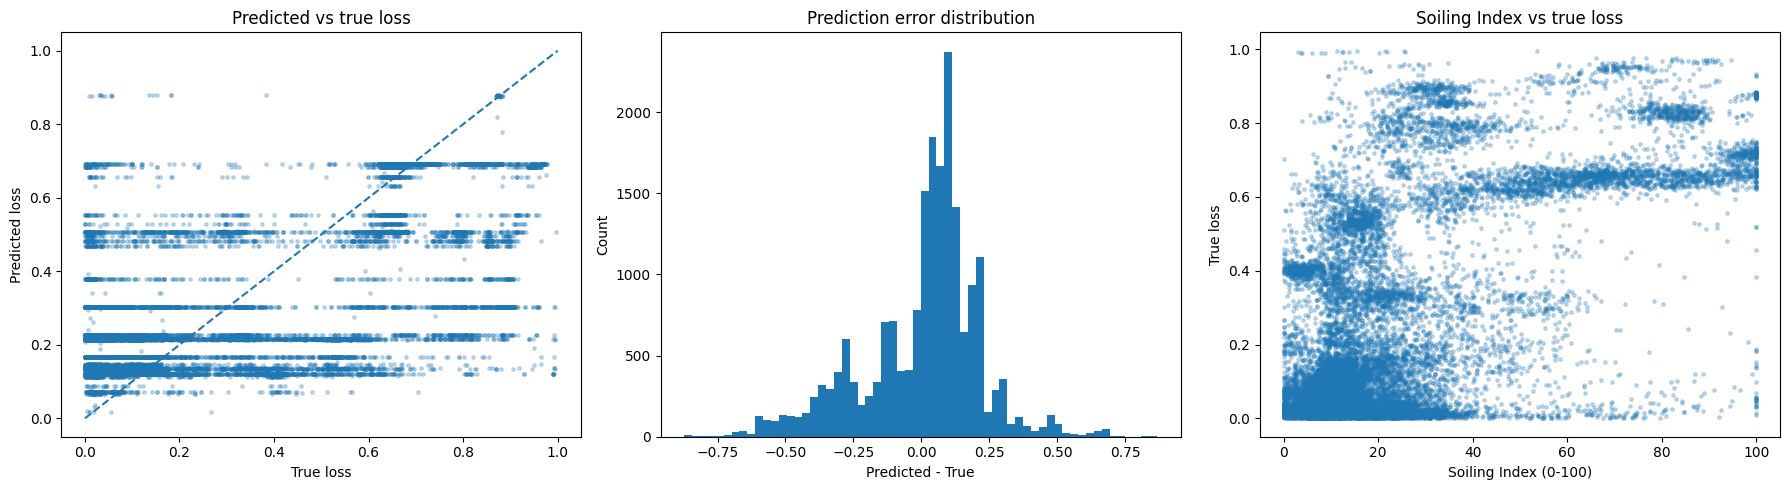

In [29]:
# Cell 24

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].scatter(y_true, y_pred, s=6, alpha=0.25)
ax[0].plot([0, 1], [0, 1], "--")
ax[0].set_xlabel("True loss")
ax[0].set_ylabel("Predicted loss")
ax[0].set_title("Predicted vs true loss")

err = y_pred - y_true
ax[1].hist(err, bins=60)
ax[1].set_title("Prediction error distribution")
ax[1].set_xlabel("Predicted - True")
ax[1].set_ylabel("Count")

ax[2].scatter(test_feats["soiling_index"], y_true, s=6, alpha=0.25)
ax[2].set_xlabel("Soiling Index (0-100)")
ax[2].set_ylabel("True loss")
ax[2].set_title("Soiling Index vs true loss")

plt.tight_layout()
plt.show()

In [30]:
# Cell 25

results_summary = {
    "weights_A_C_T_N": w.tolist(),
    "column_max_A_C_T_N": col_max.tolist(),
    "score_min": score_min,
    "score_max": score_max,
    "test_metrics": {
        "pearson": float(pear),
        "spearman": float(spear),
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "event_accuracy_loss_ge_5pct": float(event_acc),
        "within_pm_5pct_loss_accuracy": float(tol_acc),
        "severity_bucket_accuracy": float(bucket_acc)
    },
    "config": {
        "IMG_W": IMG_W,
        "IMG_H": IMG_H,
        "TOP_FRAC": TOP_FRAC,
        "BOTTOM_FRAC": BOTTOM_FRAC,
        "LEFT_FRAC": LEFT_FRAC,
        "RIGHT_FRAC": RIGHT_FRAC
    }
}

with open(os.path.join(ARTIFACT_DIR, "classical_soiling_model.json"), "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved to:", os.path.join(ARTIFACT_DIR, "classical_soiling_model.json"))

Saved to: /content/soiling_artifacts/classical_soiling_model.json


In [31]:
# Cell 26

def infer_single_image(path, show=True):
    img = read_bgr(path)
    feat = extract_classical_features(img)

    score_raw = raw_soiling_index_from_components(feat["A"], feat["C"], feat["T"], feat["N"], w, col_max)
    si = score_to_si(score_raw)
    pred_loss = score_to_loss(score_raw)

    if show:
        fig, ax = plt.subplots(2, 3, figsize=(16, 9))
        ax[0,0].imshow(bgr_to_rgb(feat["proc"]["raw_resized"]))
        ax[0,0].set_title("Raw original / resized")

        ax[0,1].imshow(bgr_to_rgb(feat["proc"]["bgr_eq"]))
        ax[0,1].set_title("Processed / normalized")

        ax[0,2].imshow(feat["mask"], cmap="gray")
        ax[0,2].set_title("Detected soiling mask")

        ax[1,0].imshow(feat["combined_blur"], cmap="inferno")
        ax[1,0].set_title("Combined dirt map")

        overlay = bgr_to_rgb(feat["proc"]["bgr_eq"]).copy()
        overlay_mask = feat["mask"].astype(bool)
        overlay[overlay_mask] = (0.7 * overlay[overlay_mask] + 0.3 * np.array([255, 0, 0])).astype(np.uint8)
        ax[1,1].imshow(overlay)
        ax[1,1].set_title("Overlay")

        txt = (
            f"Soiling Index: {si:.2f} / 100\n"
            f"Estimated Loss: {pred_loss*100:.2f}%\n"
            f"A={feat['A']:.4f}\n"
            f"C={feat['C']:.4f}\n"
            f"T={feat['T']:.4f}\n"
            f"N={feat['N']:.4f}"
        )
        ax[1,2].text(0.05, 0.5, txt, fontsize=14, va="center")
        ax[1,2].axis("off")
        ax[1,2].set_title("Final outputs")

        for a in ax.ravel():
            if a != ax[1,2]:
                a.axis("off")

        plt.tight_layout()
        plt.show()

    return {
        "soiling_index": si,
        "estimated_loss": pred_loss,
        "A": feat["A"],
        "C": feat["C"],
        "T": feat["T"],
        "N": feat["N"]
    }

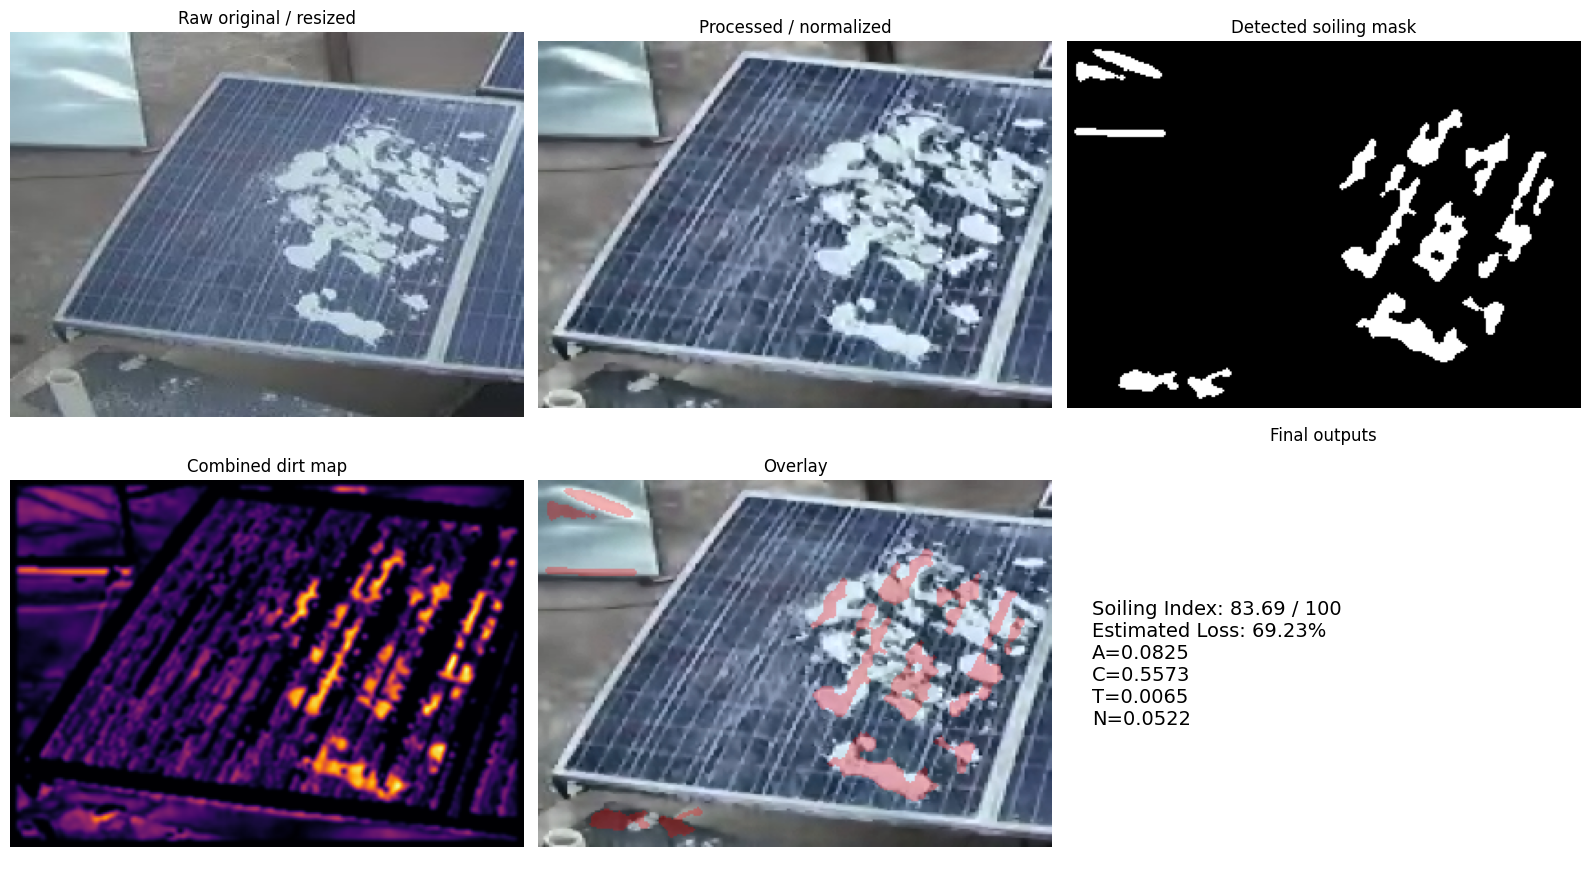

{'soiling_index': 83.68511016316266, 'estimated_loss': 0.6922959217383489, 'A': 0.08248791629043395, 'C': 0.5572804808616638, 'T': 0.006490609142929316, 'N': 0.05218195306781916}


In [32]:
# Cell 27

# Example: choose any dataset image
my_test_image = test_feats.sample(1, random_state=SEED).iloc[0]["path"]

result = infer_single_image(my_test_image, show=True)
print(result)

Saving Imgdirty_949_1.jpg to Imgdirty_949_1.jpg
Testing: Imgdirty_949_1.jpg


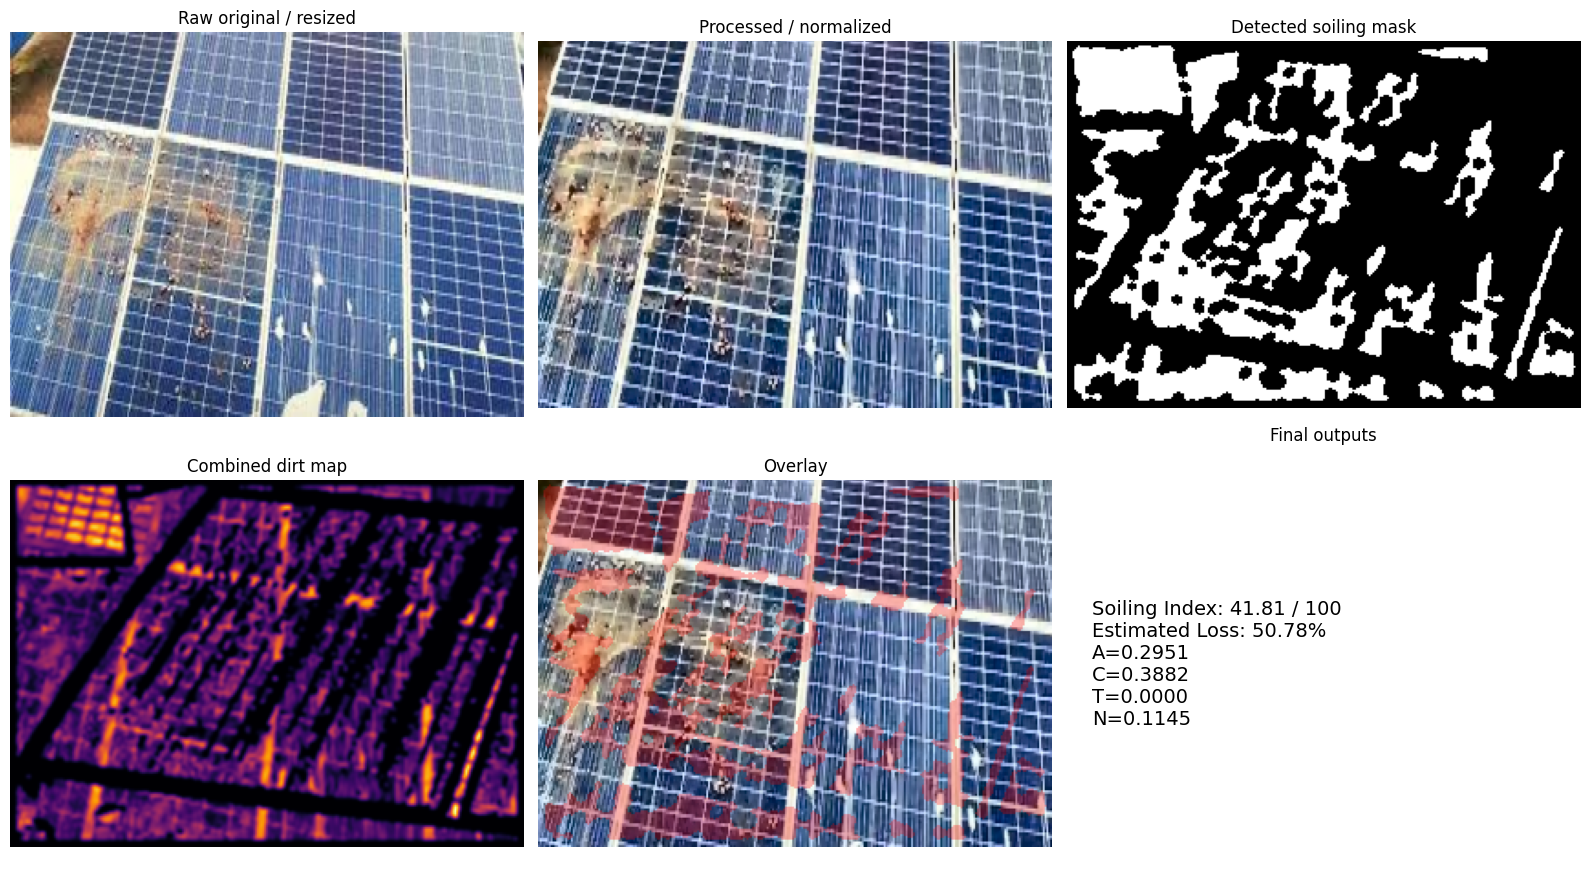

In [33]:
# Cell 28

from google.colab import files

uploaded = files.upload()

for fname in uploaded.keys():
    print("Testing:", fname)
    infer_single_image(fname, show=True)

In [34]:
# Cell 29

# This cell just prints the minimal parameters you need later on Raspberry Pi

print("Use these learned weights later:")
print("w =", w.tolist())
print("col_max =", col_max.tolist())
print("score_min =", score_min)
print("score_max =", score_max)
print("Reference image saved at:", os.path.join(ARTIFACT_DIR, "reference_bgr.png"))
print("Model summary saved at:", os.path.join(ARTIFACT_DIR, "classical_soiling_model.json"))

Use these learned weights later:
w = [0.0, 0.9724659316952562, 0.02753405308694289, 0.0]
col_max = [0.3375825498840318, 0.6861317157745361, 0.13173842430114746, 0.26278535971921857]
score_min = 0.30961246811630905
score_max = 0.8850876291337197
Reference image saved at: /content/soiling_artifacts/reference_bgr.png
Model summary saved at: /content/soiling_artifacts/classical_soiling_model.json


Saving solar_Fri_Jun_16_10__10__48_2017_L_0.893132408441_I_0.295105882353.jpg to solar_Fri_Jun_16_10__10__48_2017_L_0.893132408441_I_0.295105882353.jpg
Testing: solar_Fri_Jun_16_10__10__48_2017_L_0.893132408441_I_0.295105882353.jpg


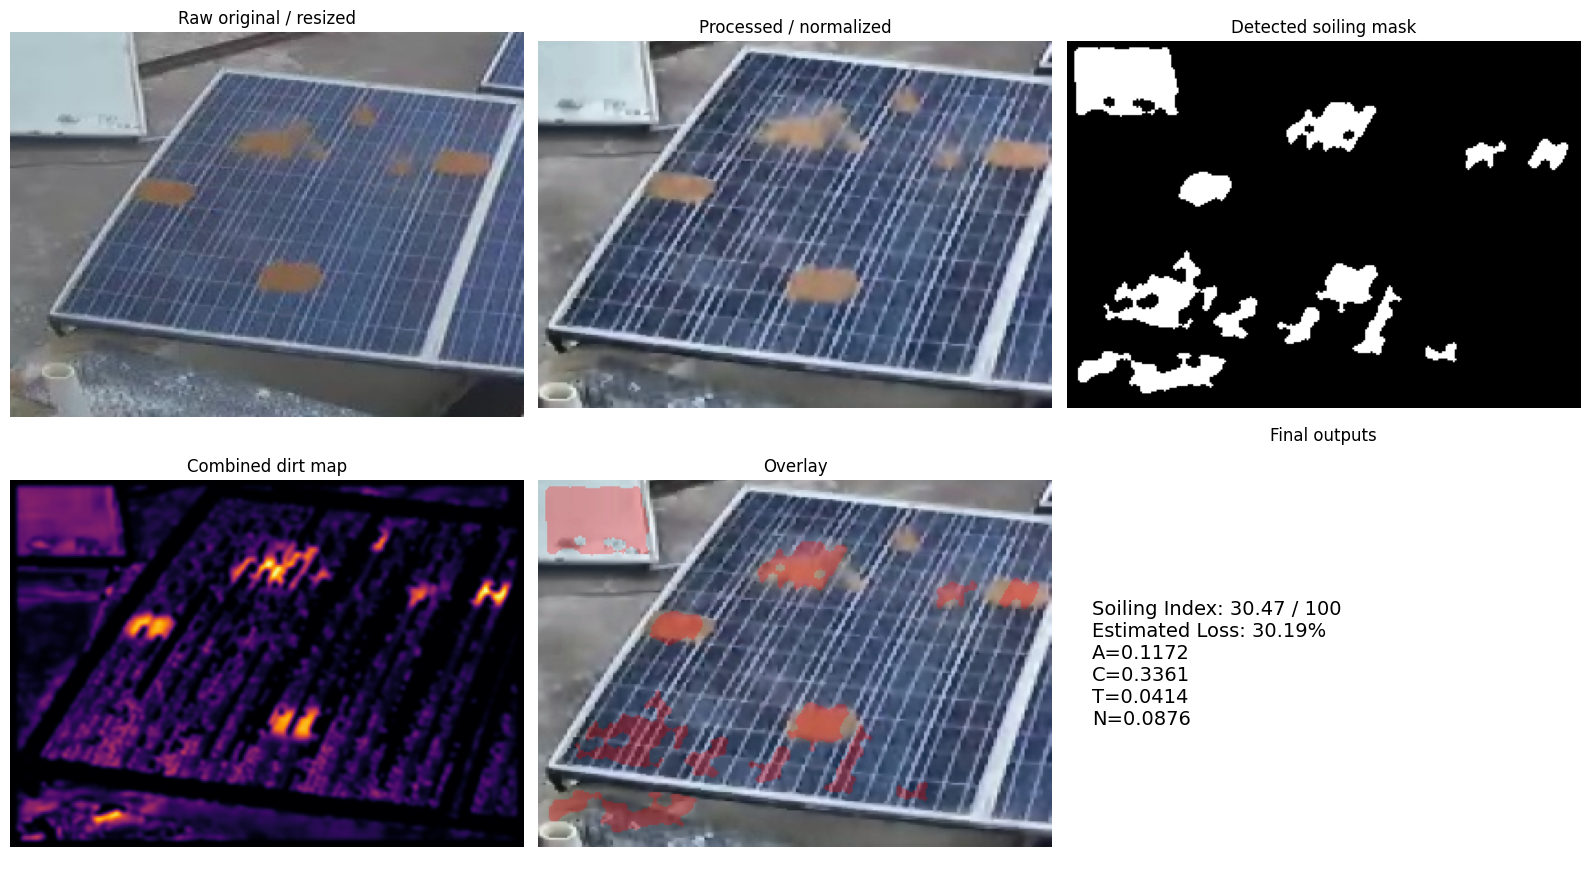

In [35]:
# Cell 30

from google.colab import files

uploaded = files.upload()

for fname in uploaded.keys():
    print("Testing:", fname)
    infer_single_image(fname, show=True)